In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
PROJECT_ROOT = HERE.parent if HERE.name == "notebooks" else HERE
for path in (PROJECT_ROOT / "src", PROJECT_ROOT.parent):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, _ = tilt.load_tilt_tables(paths)
df_eddies = tilt.add_region_labels(df_eddies, grid)
# df_eddies = tilt.add_pv_gradient_terms(df_eddies, grid, core_mean=True)
df_eddies.head()

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir,Region
0,1,1462,CE,152.716333,-38.866383,171,26,474.560686,127.605656,-0.000032,...,29.449052,7.225911,1.973172,20.004291,26,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1
1,1,1463,CE,152.836206,-38.814279,173,28,482.821993,136.635735,-0.000041,...,29.449052,7.225911,1.859668,18.906549,26,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1
2,1,1464,CE,152.905198,-38.816261,175,28,488.606048,138.480541,-0.000035,...,32.090160,7.712683,1.745185,20.859920,26,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1
3,1,1465,CE,152.719389,-38.902070,171,25,475.960098,123.953440,-0.000020,...,34.827275,8.275696,1.433213,18.674495,26,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,19.823350,87.507772,D1
4,1,1466,CE,152.753007,-38.935135,172,25,479.803789,121.483614,-0.000026,...,37.564389,8.838709,1.140614,21.564028,26,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,15.055658,105.302388,D1


In [2]:
old_eddy = [int(df_eddies[df_eddies.Age==df_eddies.Age.max()].Eddy.iloc[0])]
df_old = df_eddies[df_eddies.Eddy==old_eddy[0]].copy()
df_old = tilt.add_pv_gradient_terms(df_old, grid, core_mean=False)
df_old

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,PV_grad_plan_theta,PV_grad_topo_mag,PV_grad_topo_theta,PV_grad_mag,PV_grad_theta,dtheta_PV_grad,dtheta_PV_grad_topo,dtheta_PV_grad_plan,Ro,topo_plan_ratio
43713,1015,4601,AE,154.625204,-29.973576,131,226,341.884291,1117.115941,0.000017,...,180.0,1.030640e-14,103.318893,1.210546e-14,124.056599,NaN,NaN,NaN,0.234308,0.850046
43714,1015,4602,AE,154.638892,-30.291028,135,220,354.203600,1084.461857,0.000021,...,180.0,1.782076e-14,276.300272,1.787458e-14,262.293329,NaN,NaN,NaN,0.279903,1.409581
43715,1015,4603,AE,154.660017,-30.435337,137,217,361.141818,1070.100890,0.000017,...,180.0,1.827145e-14,276.743605,1.827715e-14,263.106897,NaN,NaN,NaN,0.226288,1.437666
43716,1015,4604,AE,154.683247,-30.496872,139,216,365.388419,1064.441285,0.000015,...,180.0,1.382737e-14,290.882658,1.293401e-14,272.753084,61.644619,79.774193,31.108465,0.196584,1.166271
43717,1015,4605,AE,154.745612,-30.542783,141,215,372.644838,1061.690838,0.000015,...,180.0,8.013983e-15,315.726525,5.781293e-15,284.606986,82.261479,113.381018,22.345507,0.207602,0.627195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44170,1015,5058,AE,150.074035,-38.715688,95,13,251.457789,65.098713,0.000064,...,180.0,5.792442e-14,322.186269,5.461180e-14,319.436883,22.045839,19.296453,161.482722,0.703473,2.606889
44171,1015,5059,AE,150.087290,-38.716148,95,13,252.563741,65.441926,0.000064,...,180.0,5.724810e-14,322.186269,5.393627e-14,319.402421,9.143927,6.360078,148.546348,0.706935,2.595144
44172,1015,5060,AE,149.981025,-38.782466,93,11,246.143788,55.420844,0.000059,...,180.0,6.090006e-14,309.963897,5.828148e-14,306.785220,NaN,NaN,NaN,0.642641,2.670238
44173,1015,5061,AE,149.932726,-38.840772,92,10,244.214852,47.943492,0.000057,...,180.0,1.051004e-13,286.327682,1.039720e-13,284.050037,NaN,NaN,NaN,0.621064,3.194976


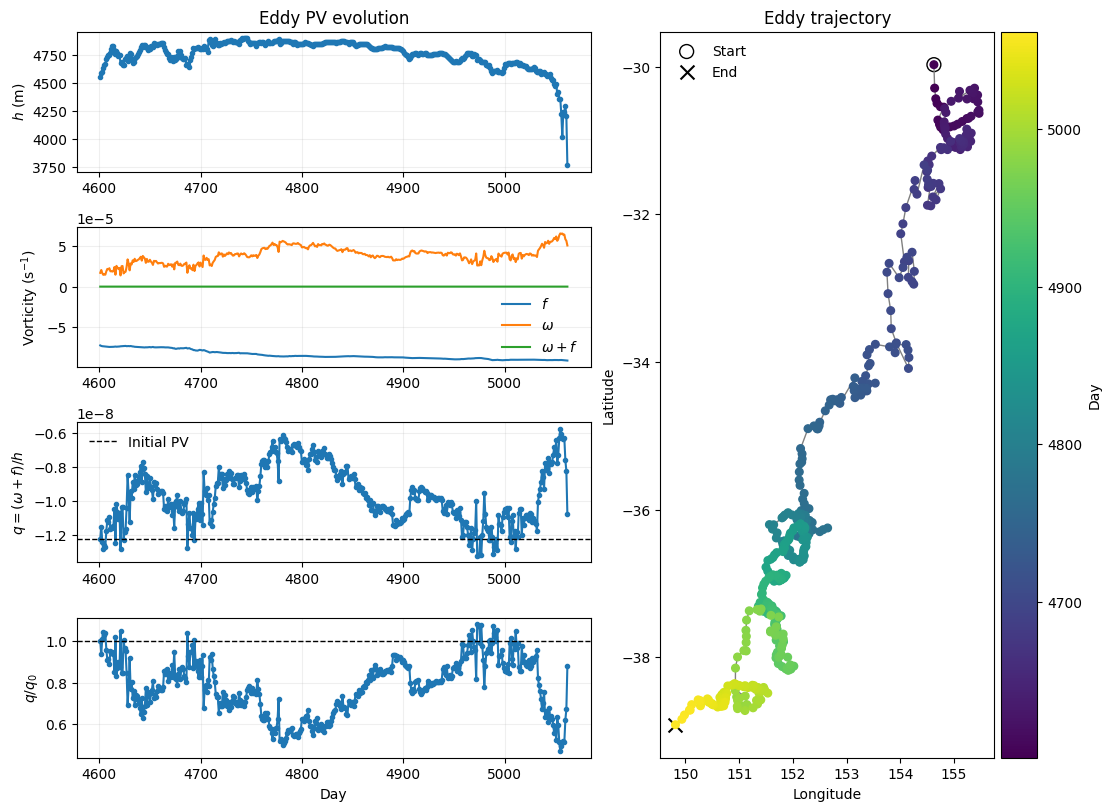

PV change over lifetime: 11.98%
PV coefficient of variation: 17.34%


In [3]:
df = df_old.copy()

# Calculate total vorticity and PV

# Normalised PV makes conservation particularly easy to see
df['PV_norm'] = df['PV'] / df['PV'].iloc[0]

fig = plt.figure(figsize=(11, 8), constrained_layout=True)
gs = fig.add_gridspec(
    4, 2,
    width_ratios=[2, 1.3]
)

axs = [fig.add_subplot(gs[i, 0]) for i in range(4)]
ax_traj = fig.add_subplot(gs[:, 1])

# --------------------------------------------------
# Time series
# --------------------------------------------------

# Depth
axs[0].plot(df.Day, df.h, 'o-', ms=3)
axs[0].set_ylabel(r'$h$ (m)')
axs[0].set_title('Eddy PV evolution')

# Planetary + relative vorticity
axs[1].plot(df.Day, df.f, label=r'$f$')
axs[1].plot(df.Day, df.w, label=r'$\omega$')
axs[1].plot(df.Day, df.PV, label=r'$\omega + f$')
axs[1].set_ylabel(r'Vorticity (s$^{-1}$)')
axs[1].legend(frameon=False)

# PV
axs[2].plot(df.Day, df.PV, 'o-', ms=3)
axs[2].axhline(
    df.PV.iloc[0],
    ls='--',
    color='k',
    lw=1,
    label='Initial PV'
)
axs[2].set_ylabel(r'$q=(\omega+f)/h$')
axs[2].legend(frameon=False)

# Normalised PV
axs[3].plot(df.Day, df.PV_norm, 'o-', ms=3)
axs[3].axhline(1, ls='--', color='k', lw=1)
axs[3].set_ylabel(r'$q/q_0$')
axs[3].set_xlabel('Day')

# Same x range for all time series
for ax in axs:
    ax.grid(alpha=0.2)

# --------------------------------------------------
# Eddy trajectory
# --------------------------------------------------

sc = ax_traj.scatter(
    df.lon,
    df.lat,
    c=df.Day,
    cmap='viridis',
    s=30,
    zorder=3
)

ax_traj.plot(
    df.lon,
    df.lat,
    color='0.5',
    lw=1,
    zorder=2
)

# Mark start/end
ax_traj.scatter(
    df.lon.iloc[0], df.lat.iloc[0],
    marker='o', s=100,
    facecolor='none', edgecolor='k',
    label='Start'
)

ax_traj.scatter(
    df.lon.iloc[-1], df.lat.iloc[-1],
    marker='x', s=100,
    color='k',
    label='End'
)

ax_traj.set_xlabel('Longitude')
ax_traj.set_ylabel('Latitude')
ax_traj.set_title('Eddy trajectory')
ax_traj.legend(frameon=False)

cbar = fig.colorbar(sc, ax=ax_traj, pad=0.02)
cbar.set_label('Day')

plt.show()

pv_change = 100 * (df.PV.iloc[-1] - df.PV.iloc[0]) / abs(df.PV.iloc[0])

pv_cv = 100 * df.PV.std() / abs(df.PV.mean())

print(f'PV change over lifetime: {pv_change:.2f}%')
print(f'PV coefficient of variation: {pv_cv:.2f}%')